<a href="https://www.kaggle.com/code/mahmoudashrey/titanic-dataset?scriptVersionId=348572082" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

,Missing Count,Missing Percentage
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


In [11]:
df = df.drop(columns = 'Cabin')

In [12]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [13]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [15]:
df.shape

(891, 11)

In [16]:
df.duplicated().sum()

np.int64(0)

### Cleaning Summary

- No duplicate rows were found.
- `Cabin` was removed because more than 77% of its values were missing.
- Missing `Age` values were replaced with the median age.
- Missing `Embarked` values were replaced with the most frequent embarkation port.
- No rows were removed during the cleaning process.

# Exploratory Data Analysis & Visualization

We begin by examining the distribution of survival outcomes to understand the overall survival rate among the passengers.

## Survival Distribution

We first examine how survival outcomes are distributed across the passengers.

In [17]:
survival_counts = df['Survived'].value_counts().sort_index()

survival_df = pd.DataFrame({
    'Survival Status': ['Did Not Survive', 'Survived'],
    'Count': survival_counts.values
})

fig = px.bar(
    survival_df,
    x = 'Survival Status',
    y = 'Count',
    text = 'Count',
    title = 'Titanic Survival Distribution',
    labels = {
        'Survival Status': 'Survival Status',
        'Count': 'Number of Passengers'
    }
)

fig.update_traces(
    textposition ='outside'
) 

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

Out of 891 passengers, 549 (61.6%) did not survive, while 342 (38.4%) survived. 
This shows that non-survivors represent the majority of the passengers in the dataset.

## Survival Rate by Gender

We examine whether survival rates differed between male and female passengers.

In [18]:
gender_survival = (
    df.groupby('Sex')['Survived']
      .mean()
      .reset_index()
)

gender_survival['Survival Rate (%)'] = gender_survival['Survived'] * 100

fig = px.bar(
    gender_survival,
    x = 'Sex',
    y = 'Survival Rate (%)',
    text = 'Survival Rate (%)',
    title = 'Survival Rate by Gender',
    labels = {
        'Sex': 'Gender',
        'Survival Rate (%)': 'Survival Rate (%)'
    }
)

fig.update_traces(
    texttemplate = '%{text:.1f}%',
    textposition = 'outside'
) 

fig.update_layout(
    title_x = 0.5,
    yaxis_range = [0, 100]
)

fig.show()

### Insight

Female passengers had a substantially higher survival rate than male passengers. 
The survival rate was 74.2% for females compared with only 18.9% for males, a difference of about 55 percentage points.

## Survival Rate by Passenger Class

We examine how survival rates varied across the three passenger classes.

In [19]:
class_survival = (
    df.groupby('Pclass')['Survived']
      .mean()
      .reset_index()
)

class_survival['Survival Rate (%)'] = class_survival['Survived'] * 100

fig = px.bar(
    class_survival,
    x = 'Pclass',
    y = 'Survival Rate (%)',
    text = 'Survival Rate (%)',
    title = 'Survival Rate by Passenger Class',
    labels = {
        'Pclass': 'Passenger Class',
        'Survival Rate (%)': 'Survival Rate (%)'
    }
)

fig.update_traces(
    texttemplate = '%{text:.1f}%',
    textposition = 'outside'
)

fig.update_layout(
    title_x = 0.5,
    yaxis_range = [0, 100],
    xaxis = dict(
        tickmode = 'array',
        tickvals = [1, 2, 3],
        ticktext = ['1st Class', '2nd Class', '3rd Class']
    )
)

fig.show()

### Insight

Survival rates varied substantially across passenger classes. 
First-class passengers had the highest survival rate at 63.0%, followed by second-class passengers at 47.3%, while third-class passengers had the lowest rate at 24.2%. 
This shows a clear decline in survival rate from first to third class.

## Age Distribution by Survival Status

We examine how passenger ages were distributed between survivors and non-survivors.

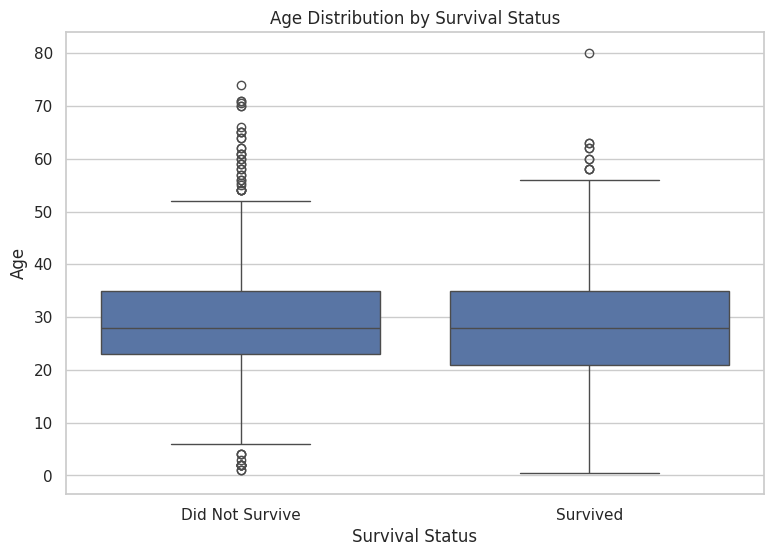

In [20]:
plt.figure(figsize = (9, 6))

sns.boxplot(
    data = df,
    x = 'Survived',
    y = 'Age'
)

plt.title('Age Distribution by Survival Status')
plt.xlabel('Survival Status')
plt.ylabel('Age')

plt.xticks(
    [0, 1],
    ['Did Not Survive', 'Survived']
)

plt.show()

### Insight

The median age is very similar for survivors and non-survivors, at around 28 years. 
Although the survivor group shows a slightly wider distribution toward younger ages, the two groups have considerable overlap. 
Overall, age alone does not show a strong separation between survival outcomes in this dataset.

## Survival Rate by Embarkation Port

We examine whether survival rates differed depending on the port where passengers boarded the Titanic.

In [21]:
embarked_survival = (
    df.groupby('Embarked')['Survived']
      .mean()
      .reset_index()
)

embarked_survival['Survival Rate (%)'] = embarked_survival['Survived'] * 100

fig = px.bar(
    embarked_survival,
    x = 'Embarked',
    y = 'Survival Rate (%)',
    text = 'Survival Rate (%)',
    title = 'Survival Rate by Embarkation Port',
    labels = {
        'Embarked': 'Embarkation Port',
        'Survival Rate (%)': 'Survival Rate (%)'
    }
)

fig.update_traces(
    texttemplate = '%{text:.1f}%',
    textposition = 'outside'
)

fig.update_layout(
    title_x = 0.5,
    yaxis_range = [0, 100]
)

fig.show()

### Insight

Survival rates varied across the three embarkation ports. 
Passengers who embarked at Cherbourg (C) had the highest survival rate at 55.4%, followed by Queenstown (Q) at 39.0%, while Southampton (S) had the lowest rate at 33.9%. 
However, these differences may also reflect differences in passenger characteristics and class across the ports rather than the embarkation port itself.

## Fare Distribution by Survival Status

We examine how ticket fares were distributed between survivors and non-survivors.

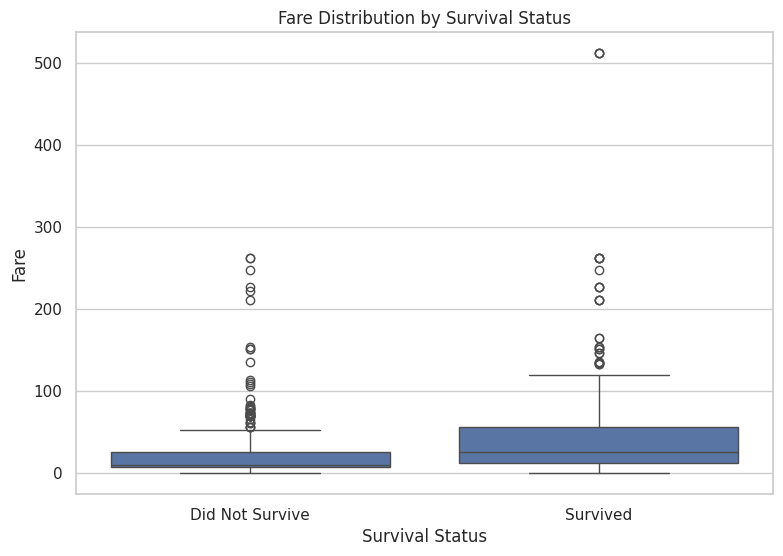

In [22]:
plt.figure(figsize = (9, 6))

sns.boxplot(
    data = df,
    x = 'Survived',
    y = 'Fare'
)

plt.title('Fare Distribution by Survival Status')
plt.xlabel('Survival Status')
plt.ylabel('Fare')

plt.xticks(
    [0, 1],
    ['Did Not Survive', 'Survived']
)

plt.show()

### Insight

Survivors generally paid higher ticket fares than non-survivors. 
The median fare for survivors is noticeably higher, and their fare distribution is also more spread out. 
Both groups contain several high-fare outliers, including an extreme fare above 500 among survivors.

## Survival Rate by Family Size

We combine the number of siblings, spouses, parents, and children aboard to examine whether family size was associated with survival rates.

In [23]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

family_survival = (
    df.groupby('FamilySize')['Survived']
      .mean()
      .reset_index()
)

family_survival['Survival Rate (%)'] = family_survival['Survived'] * 100

fig = px.bar(
    family_survival,
    x = 'FamilySize',
    y = 'Survival Rate (%)',
    text = 'Survival Rate (%)',
    title = 'Survival Rate by Family Size',
    labels = {
        'FamilySize': 'Family Size',
        'Survival Rate (%)': 'Survival Rate (%)'
    }
)

fig.update_traces(
    texttemplate = '%{text:.1f}%',
    textposition = 'outside'
)

fig.update_layout(
    title_x = 0.5,
    yaxis_range = [0, 100]
)

fig.show()

### Insight

Survival rates varied considerably across family sizes. 
Passengers traveling in smaller families, particularly family sizes of 2–4, generally showed higher survival rates, while survival rates dropped for family sizes of 5–6. 
Very large family sizes show extremely low or zero survival rates, but these groups contain relatively few passengers and should therefore be interpreted with caution.

## Correlation Analysis

We examine the correlations between the numerical variables and survival outcome to identify the variables most strongly associated with survival.

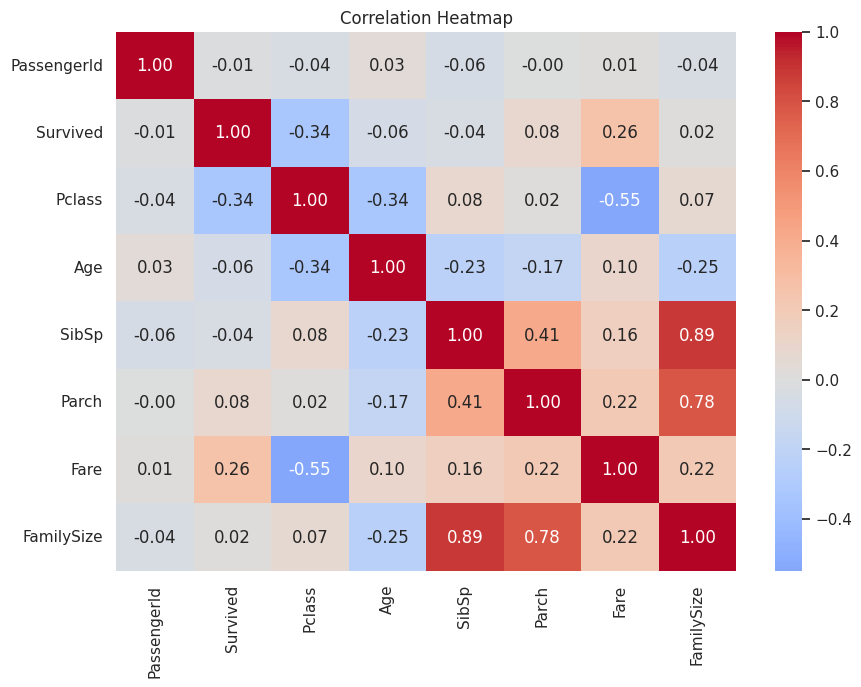

In [24]:
correlation_matrix = df.select_dtypes(include = 'number').corr()

plt.figure(figsize = (10, 7))

sns.heatmap(
    correlation_matrix,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0
)

plt.title('Correlation Heatmap')
plt.show()

### Insight

Passenger class shows the strongest numerical correlation with survival (-0.34), indicating that survival rates tended to be lower for higher class numbers. 
Fare also has a moderate positive correlation with survival (0.26), while Age, SibSp, Parch, and FamilySize show only weak correlations with the outcome.

The strong correlations between FamilySize and its components, SibSp and Parch, are expected because FamilySize was derived from these variables.

## Survival Rate by Gender and Passenger Class

We examine survival rates across combinations of gender and passenger class to understand how these two factors interacted with survival outcomes.

In [25]:
gender_class_survival = (
    df.groupby(['Sex', 'Pclass'])['Survived']
      .mean()
      .reset_index()
)

gender_class_survival['Survival Rate (%)'] = (gender_class_survival['Survived'] * 100)

heatmap_data = gender_class_survival.pivot(
    index = 'Sex',
    columns = 'Pclass',
    values = 'Survival Rate (%)'
)

fig = px.imshow(
    heatmap_data,
    text_auto = '.1f',
    aspect = 'auto',
    color_continuous_scale = 'Blues',
    title = 'Survival Rate by Gender and Passenger Class',
    labels = {
        'x': 'Passenger Class',
        'y': 'Gender',
        'color': 'Survival Rate (%)'
    }
)

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

Survival rates varied substantially across combinations of gender and passenger class. 
Female passengers had much higher survival rates than males within every passenger class, with the highest rate among first-class females at 96.8%. 
Among male passengers, survival rates were considerably lower, ranging from 36.9% in first class to 13.5% in third class.

# Key Findings

- Out of 891 passengers, 38.4% survived while 61.6% did not survive.

- Gender showed one of the strongest differences in survival rates. Female passengers had a survival rate of 74.2%, compared with only 18.9% for male passengers.

- Passenger class was also strongly associated with survival. First-class passengers had the highest survival rate at 63.0%, while third-class passengers had the lowest at 24.2%.

- Age showed substantial overlap between survivors and non-survivors, with both groups having a median age of around 28 years. Therefore, age alone does not provide a strong separation between the two groups.

- Survivors generally paid higher fares than non-survivors, and the survivor group showed a wider fare distribution.

- Survival rates varied across family sizes. Smaller families, particularly those with 2–4 members, generally showed higher survival rates, while very large family sizes had lower rates but should be interpreted cautiously due to smaller group sizes.

- Survival rates also differed across embarkation ports, with Cherbourg showing the highest rate at 55.4% and Southampton the lowest at 33.9%. These differences may partly reflect differences in passenger characteristics and class.

- The correlation analysis showed that Pclass had the strongest numerical correlation with survival (-0.34), followed by Fare (0.26).

- The combination of gender and passenger class revealed particularly large differences in survival rates. Female passengers had substantially higher survival rates than males across all three passenger classes.

# Conclusion

This exploratory analysis provided an overview of the factors associated with passenger survival on the Titanic.

The analysis showed clear differences in survival rates based on gender and passenger class. Female passengers had substantially higher survival rates than male passengers, while first-class passengers had higher survival rates than those in second and third class.

Fare was also generally higher among survivors, while age showed considerable overlap between survivors and non-survivors. Family size showed a non-linear relationship with survival, and survival rates also varied across embarkation ports.

Overall, gender and passenger class stood out as the most noticeable factors associated with survival in this dataset. The analysis highlights how exploratory data analysis and visualization can be used to uncover meaningful patterns and relationships within historical data.